In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, auc, roc_curve
import itertools
import yaml
import os
import numpy as np
from statistics import mean

In [2]:
def plot_confusion_matrix(y_true, y_pred, classes,
                          normalize=False,
                          title='Matriz de Confusión',
                          cmap=plt.cm.Blues):
    """
    Esta función imprime y plotea la matriz de confusión.
    La normalización se puede aplicar configurando `normalize=True`.
    """
    cm = confusion_matrix(y_true, y_pred)

    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    plt.figure(figsize=(6, 4))
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.ylabel('Etiqueta Verdadera')
    plt.xlabel('Etiqueta Predicha')
    plt.tight_layout()

In [3]:
path = 'mode_train-model_None-trainwindow_0-trainperiod_0-tradingstrategy_strategies.macd_strategy'
orders = pd.read_csv(os.path.join('./data', path, 'orders.csv'))
wallet = pd.read_csv(os.path.join('./data', path, 'wallet.csv'))
# true_values = pd.read_csv(os.path.join('./data', path, 'stock_true_values.csv'))
# predictions = pd.read_csv(os.path.join('./data', path, 'stock_predictions.csv'))
prices = pd.read_csv(os.path.join('./data', 'ypf.csv'))

In [4]:
orders

,id,ticker,type,open_date,close_date,open_price,close_price,profit
0,c8c3c63e-5cb0-11ef-9ae0-97f7941204fc,TEO,buy,2013-01-02,2013-02-07,7.362530,9.620452,2.257922
1,c8ce53e6-5cb0-11ef-83a2-97f7941204fc,EDN,buy,2013-01-04,2013-02-05,2.000000,2.730000,0.730000
2,c918c097-5cb0-11ef-8d9d-97f7941204fc,YPF,buy,2013-01-29,2013-02-08,16.670801,16.183577,-0.487225
3,c94d95e8-5cb0-11ef-ab05-97f7941204fc,BBAR,buy,2013-02-14,2013-02-19,3.463521,3.328393,-0.135127
4,c9933de9-5cb0-11ef-8c9b-97f7941204fc,BMA,buy,2013-03-06,2013-03-27,10.297272,9.840056,-0.457215
...,...,...,...,...,...,...,...,...
885,ff7ef737-5cb0-11ef-b573-97f7941204fc,YPF,buy,2023-07-05,2023-07-06,15.150000,14.050000,-1.099999
886,ff946bb5-5cb0-11ef-b171-97f7941204fc,LOMA,buy,2023-07-10,2023-07-12,6.730000,6.800000,0.070000
887,ffa77e72-5cb0-11ef-8d0a-97f7941204fc,LOMA,buy,2023-07-13,2023-07-14,7.060000,6.750000,-0.310000
888,ffc4f96b-5cb0-11ef-8074-97f7941204fc,CEPU,buy,2023-07-20,2023-07-27,6.239815,5.973535,-0.266280


In [5]:
# with open('configs/project_config.yml', 'r') as archivo:
#     config = yaml.safe_load(archivo)

# tickers = config["tickers"] 
# tickers

# predictions = predictions.sort_values(by='fecha')
# true_values = true_values.sort_values(by='fecha')


# # renombro las columnas
# column_names = {}
# for column in predictions.columns:
#     if column != 'fecha':
#         column_names[column] = f'{column}_proba'

# predictions = predictions.rename(columns=column_names)

# column_names = {}
# for column in true_values.columns:
#     if column != 'fecha':
#         column_names[column] = f'{column}_true'

# true_values = true_values.rename(columns=column_names)
# performance = pd.concat(
#     [
#         predictions,
#         true_values
#     ], axis=1, join="inner"
# )

# auc_list = []
# for ticker in tickers:
#     y_true = performance[performance[f'{ticker}_true'].notna()][f'{ticker}_true']
#     y_pred = performance[performance[f'{ticker}_proba'].notna()][f'{ticker}_proba']
    
#     fpr, tpr, thresholds = roc_curve(y_true, y_pred)
#     auc_score = auc(fpr, tpr)
    
#     auc_list.append(auc_score)
#     print(f'{ticker}: {auc_score}')

# print(mean(auc_list))

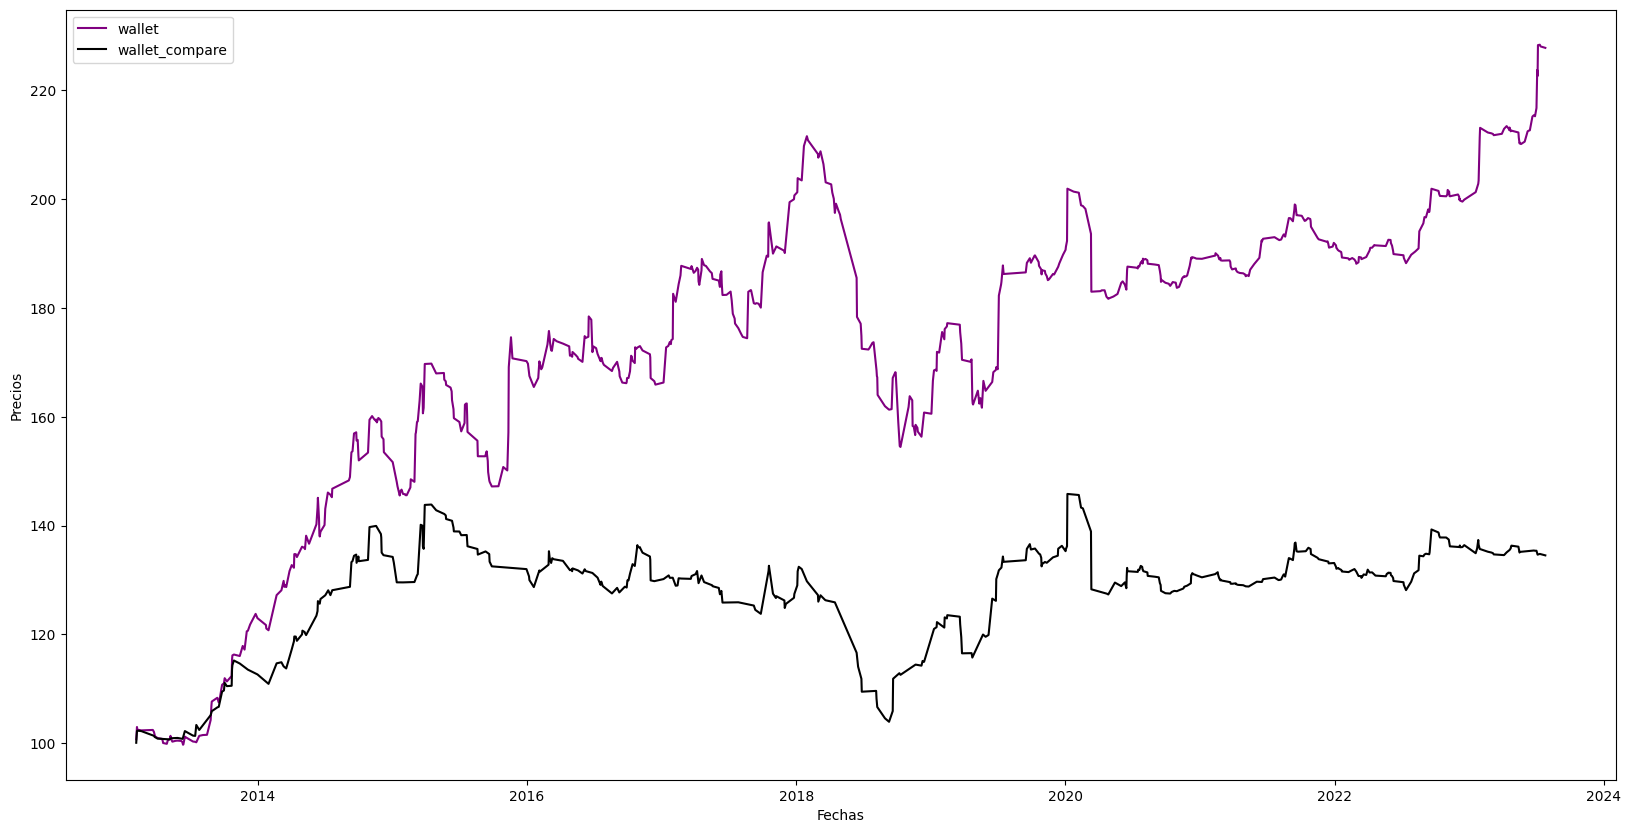

In [6]:
import matplotlib.pyplot as plt
import numpy as np

wallet_compare = None
try:
    path_compare = 'mode_train-model_random_forest-trainwindow_76-trainperiod_7-tradingstrategy_strategies.macd_strategy'
    wallet_compare = pd.read_csv(os.path.join('./data', path_compare, 'wallet.csv'))

except:
    pass

# Datos de ejemplo
x_wallet = pd.to_datetime(wallet['date'])
y_wallet = wallet['wallet']  # Datos para la línea

# Crear una figura y ejes
fig, ax = plt.subplots(figsize=(20, 10))

# Agregar la línea
ax.plot(x_wallet, y_wallet, label='wallet', color='purple')

x_compare = pd.to_datetime(wallet_compare['date'])
y_compare = wallet_compare['wallet']  # Datos para la línea
ax.plot(x_compare, y_compare, label='wallet_compare', color='black')


# Etiquetas de los ejes y leyenda
ax.set_xlabel('Fechas')
ax.set_ylabel('Precios')
ax.legend()

# Mostrar el gráfico
plt.show()


In [7]:
orders

,id,ticker,type,open_date,close_date,open_price,close_price,profit
0,c8c3c63e-5cb0-11ef-9ae0-97f7941204fc,TEO,buy,2013-01-02,2013-02-07,7.362530,9.620452,2.257922
1,c8ce53e6-5cb0-11ef-83a2-97f7941204fc,EDN,buy,2013-01-04,2013-02-05,2.000000,2.730000,0.730000
2,c918c097-5cb0-11ef-8d9d-97f7941204fc,YPF,buy,2013-01-29,2013-02-08,16.670801,16.183577,-0.487225
3,c94d95e8-5cb0-11ef-ab05-97f7941204fc,BBAR,buy,2013-02-14,2013-02-19,3.463521,3.328393,-0.135127
4,c9933de9-5cb0-11ef-8c9b-97f7941204fc,BMA,buy,2013-03-06,2013-03-27,10.297272,9.840056,-0.457215
...,...,...,...,...,...,...,...,...
885,ff7ef737-5cb0-11ef-b573-97f7941204fc,YPF,buy,2023-07-05,2023-07-06,15.150000,14.050000,-1.099999
886,ff946bb5-5cb0-11ef-b171-97f7941204fc,LOMA,buy,2023-07-10,2023-07-12,6.730000,6.800000,0.070000
887,ffa77e72-5cb0-11ef-8d0a-97f7941204fc,LOMA,buy,2023-07-13,2023-07-14,7.060000,6.750000,-0.310000
888,ffc4f96b-5cb0-11ef-8074-97f7941204fc,CEPU,buy,2023-07-20,2023-07-27,6.239815,5.973535,-0.266280


# Grafico de velas

In [8]:
# import plotly.graph_objects as go

# fig = go.Figure(data=[go.Candlestick(x=prices['Date'],
#                 open=prices['Open'],
#                 high=prices['High'],
#                 low=prices['Low'],
#                 close=prices['Close'])])

# fig.update_layout(
#     title=f"{config['ticker']}",
#     yaxis_title=f"{config['ticker']} Stock"
# )

# fig.show()

# Estrategia

In [9]:
import matplotlib.pyplot as plt
import numpy as np

# Datos de ejemplo
x_prices = pd.to_datetime(prices['Date'])
y_prices = prices['Close']  # Datos para la línea

x_buy = pd.to_datetime(buys['fecha'])
y_buy = buys['buy']  # Datos para el scatter plot

x_sell = pd.to_datetime(sells['date'])
y_sell = sells['sell']  # Datos para el scatter plot

x_wallet = pd.to_datetime(wallet['date'])
y_wallet = wallet['wallet']  # Datos para la línea

# Crear una figura y ejes
fig, ax = plt.subplots(figsize=(20, 10))

# Agregar la línea
ax.plot(x_prices, y_prices, label='market', color='black')

ax.plot(x_wallet, y_wallet, label='wallet', color='purple')

# Agregar el scatter plot
ax.scatter(x_buy, y_buy, label='compras', color='cyan', marker='>')

ax.scatter(x_sell, y_sell, label='Ventas', color='red', marker='o')

# Etiquetas de los ejes y leyenda
ax.set_xlabel('Fechas')
ax.set_ylabel('Precios')
ax.legend()

# Mostrar el gráfico
plt.show()


NameError: name 'buys' is not defined

In [10]:
import matplotlib.pyplot as plt
import numpy as np

# Datos de ejemplo
x_prices = pd.to_datetime(prices['Date'])
y_prices = prices['Close']  # Datos para la línea

x_buy = pd.to_datetime(buys['date'])
y_buy = buys['buy']  # Datos para el scatter plot

x_sell = pd.to_datetime(sells['date'])
y_sell = sells['sell']  # Datos para el scatter plot

# Crear una figura y ejes
fig, ax = plt.subplots(figsize=(20, 10))

# Agregar la línea
ax.plot(x_prices, y_prices, label='market', color='black')

# Agregar el scatter plot
ax.scatter(x_buy, y_buy, label='compras', color='cyan', marker='>')

ax.scatter(x_sell, y_sell, label='Ventas', color='red', marker='o')

# Etiquetas de los ejes y leyenda
ax.set_xlabel('Fechas')
ax.set_ylabel('Precios')
ax.legend()

# Mostrar el gráfico
plt.show()


NameError: name 'buys' is not defined

Area bajo la curva:  113951.7135810852


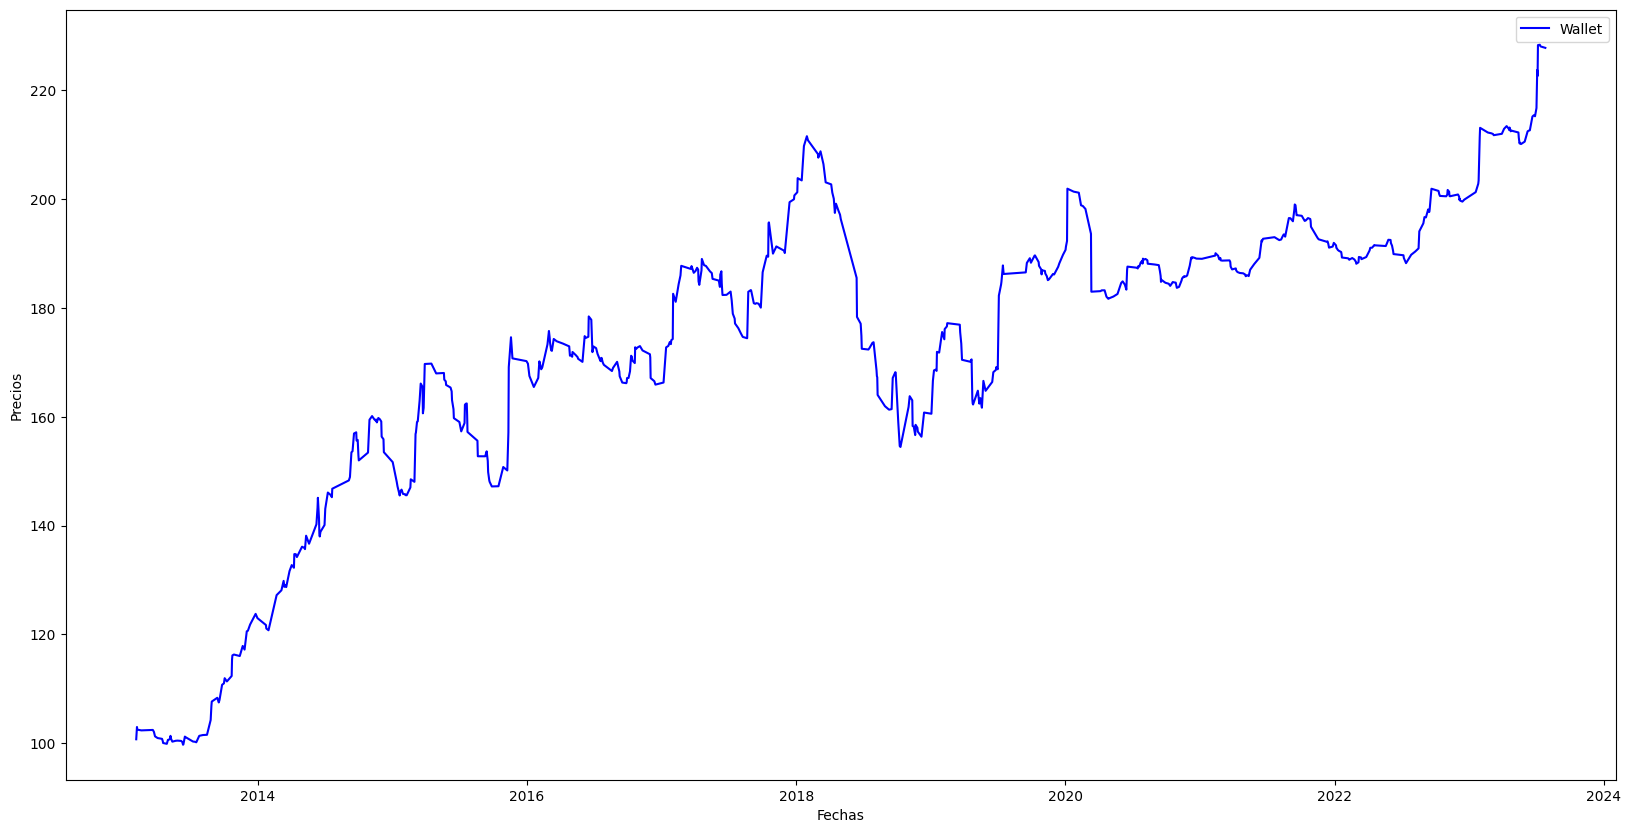

In [11]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import auc

print('Area bajo la curva: ', auc(wallet.index, wallet['wallet']))

# Datos de ejemplo
x_prices = pd.to_datetime(wallet['date'])
y_prices = wallet['wallet']  # Datos para la línea


# Crear una figura y ejes
fig, ax = plt.subplots(figsize=(20, 10))

# Agregar la línea
ax.plot(x_prices, y_prices, label='Wallet', color='blue')

# Etiquetas de los ejes y leyenda
ax.set_xlabel('Fechas')
ax.set_ylabel('Precios')
ax.legend()

# Mostrar el gráfico
plt.show()


# Modelo

In [12]:
predictions.sort_values(by='fecha')

NameError: name 'predictions' is not defined

In [ ]:
true_values.sort_values(by='fecha')

In [ ]:
accuracy_score(predictions[predictions['YPF'].notna()].YPF, true_values[true_values['YPF'].notna()].YPF)

In [ ]:
threshold_down = 0.5
threshold_up = 0.5

df_predictions = performance[(performance['y_pred']<threshold_down) | (performance['y_pred']>threshold_up)].copy()
df_predictions['y_pred'] = np.where(df_predictions['y_pred']<threshold_down, 0, df_predictions['y_pred'])
df_predictions['y_pred'] = np.where(df_predictions['y_pred']>threshold_up, 1, df_predictions['y_pred'])

print(accuracy_score(df_predictions.y_true, df_predictions.y_pred))
plot_confusion_matrix(df_predictions.y_true, df_predictions.y_pred, classes=[0,1], cmap=plt.cm.Reds)

In [ ]:
threshold_down = 0.1
threshold_up = 0.9

df_predictions = performance[(performance['y_pred']<threshold_down) | (performance['y_pred']>threshold_up)].copy()
df_predictions['y_pred'] = np.where(df_predictions['y_pred']<threshold_down, 0, df_predictions['y_pred'])
df_predictions['y_pred'] = np.where(df_predictions['y_pred']>threshold_up, 1, df_predictions['y_pred'])

print(accuracy_score(df_predictions.y_true, df_predictions.y_pred))
plot_confusion_matrix(df_predictions.y_true, df_predictions.y_pred, classes=[0,1], cmap=plt.cm.Reds)

In [ ]:
plt.hist(performance.y_pred, color='lightgreen', ec='black', bins=50)
plt.show()

In [ ]:
buys = buys.rename(columns={''})

In [ ]:
operations = pd.concat([buys[buys['YPF'].notna()], sells[sells['YPF'].notna()]], axis=1, join="inner")[['fecha','YPF']]
operations

In [ ]:
operations['positive'] = np.where(operations['buy']>operations['sell'], 0, 1)
operations['Profit'] = operations['sell'] - operations['buy'] 
operations['positive'].value_counts()